In [1]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from transformers.models.bert.modeling_bert import BertPreTrainedModel, BertModel
from sklearn.model_selection import train_test_split
import torch
import torch.nn.functional as Fun
import transformers
import matplotlib.pyplot as plt
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore') # setting ignore as a 

from datasets import load_dataset
dataset = load_dataset("imdb")

c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# get predict result
def get_pred(logits):
    # logits shape: (batch_size, num_classes)
    # 使用 argmax 選出每一筆的最大值位置 (代表預測的class)
    preds = torch.argmax(logits, dim=1)
    return preds

# calculate confusion metrics
def cal_metrics(pred, ans):
    # 把 tensor 轉成 numpy array
    pred = pred.cpu().numpy()
    ans = ans.cpu().numpy()

    acc = accuracy_score(ans, pred)
    f1 = f1_score(ans, pred, average='macro')  # 多類別情緒建議用 macro
    recall = recall_score(ans, pred, average='macro')
    precision = precision_score(ans, pred, average='macro')

    return acc, f1, recall, precision

# save model to path
def save_checkpoint(save_path, model):
  if save_path == None:
      return
  torch.save(model.state_dict(), save_path)
  print(f'Model saved to ==> {save_path}')

# load model from path
def load_checkpoint(load_path, model, device):
  if load_path==None:
      return
  state_dict = torch.load(load_path, map_location=device)
  print(f'Model loaded from <== {load_path}')

  model.load_state_dict(state_dict)
  return model

### 數據預處理

In [3]:
import re
import nlpaug.augmenter.word as naw
import random

# 文字預處理：小寫化 + 移除多餘符號
def clean_text(text):
    text = text.strip().lower()  # 去前後空白 + 全部小寫
    
    text = re.sub(r"<br\s*/?>", " ", text)  # 處理HTML的<br>標籤
    text = re.sub(r"[^a-z0-9\s.,!?']", " ", text)  # 刪除非法字元
    text = re.sub(r"([.!?,])\1{1,}", r"\1", text)  # 壓縮連續標點
    text = re.sub(r"\s+", " ", text)  # 壓縮空白
    
    return text

# EDA augmentation function
# 定義 EDA 操作
syn_aug = naw.SynonymAug(aug_src='wordnet', aug_min=1, aug_max=1)
drop_aug = naw.RandomWordAug(action="delete", aug_p=0.05)


def apply_eda(text, num_aug=2):
    augmented_texts = []
    if not isinstance(text, str) or not text.strip():
        return []

    for _ in range(num_aug):
        try:
            # 隨機決定是 synonym augmentation 還是 random drop
            if random.random() < 0.5:
                aug_text = syn_aug.augment(text)
            else:
                aug_text = drop_aug.augment(text)

            # 如果返回的是 list，取第一個
            if isinstance(aug_text, list):
                if len(aug_text) > 0:
                    aug_text = aug_text[0]
                else:
                    continue

            # 確保是乾淨文字
            if isinstance(aug_text, str) and aug_text.strip():
                clean_aug_text = clean_text(aug_text)  # 🌟 這裡一定要 clean
                augmented_texts.append(clean_aug_text)

        except Exception as e:
            # 出錯時用原始文字 clean 後補上
            clean_orig_text = clean_text(text)
            augmented_texts.append(clean_orig_text)

    return augmented_texts

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 先取出資料
train_data = dataset['train']
test_data = dataset['test']

# 把 train 和 test 合併
all_data = pd.DataFrame({
    'text': train_data['text'] + test_data['text'],
    'label': train_data['label'] + test_data['label']
})

# 重新切割成新的 train/test (例如 80% train, 20% test)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    all_data['text'], 
    all_data['label'], 
    test_size=0.2, 
    random_state=42,
    stratify=all_data['label'] # 保持分類比例一樣
)

# 把切好的資料整理成 DataFrame
train_df = pd.DataFrame({'text': train_texts, 'label': train_labels})
test_df = pd.DataFrame({'text': test_texts, 'label': test_labels})

# --- 新增計算平均字串長度 ---
train_lengths = train_df['text'].apply(lambda x: len(x))
test_lengths = test_df['text'].apply(lambda x: len(x))

# 計算每一筆資料的字數（以空格分隔）
train_word_counts = train_df['text'].apply(lambda x: len(x.split()))
test_word_counts = test_df['text'].apply(lambda x: len(x.split()))

print(f"New train size: {len(train_df)}, New test size: {len(test_df)}")
print(f"Train set 平均字串長度: {train_lengths.mean():.2f} 字元")
print(f"Test set 平均字串長度: {test_lengths.mean():.2f} 字元")
print(f"Train set 平均字數: {train_word_counts.mean():.2f} 字")
print(f"Test set 平均字數: {test_word_counts.mean():.2f} 字")
train_df.head()

all_data['label'].value_counts() / len(all_data)

New train size: 40000, New test size: 10000
Train set 平均字串長度: 1308.34 字元
Test set 平均字串長度: 1313.79 字元
Train set 平均字數: 230.94 字
Test set 平均字數: 232.02 字


label
0    0.5
1    0.5
Name: count, dtype: float64

In [5]:
from sklearn.model_selection import train_test_split

train_df, temp_data = train_test_split(all_data, random_state=1111, train_size=0.8)
dev_df, test_df = train_test_split(temp_data, random_state=1111, train_size=0.5)
print('# of train_df:', len(train_df))
print('# of dev_df:', len(dev_df))
print('# of test_df data:', len(test_df))

# save data
train_df.to_csv('./train.tsv', sep='\t', index=False)
dev_df.to_csv('./val.tsv', sep='\t', index=False)
test_df.to_csv('./test.tsv', sep='\t', index=False)

# of train_df: 40000
# of dev_df: 5000
# of test_df data: 5000


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
import torch
import torch.nn.functional as Fun

# Using Dataset to build DataLoader
class CustomDataset(Dataset):
    def __init__(self, mode, df, specify, args):
        assert mode in ["train", "val", "test"]
        self.mode = mode
        self.df = df
        self.specify = specify
        self.tokenizer = AutoTokenizer.from_pretrained(args["config"])
        self.max_len = args["max_len"]
        self.num_class = args["num_class"]
        self.use_token_type = "token_type_ids" in self.tokenizer.model_input_names  # ✅ 判斷是否有 token_type_ids

        if self.mode != 'test':
            self.label = df['label']

    def __len__(self):
        return len(self.df)

    # transform label to one_hot label (if num_class > 2)
    def one_hot_label(self, label):
        return Fun.one_hot(torch.tensor(label), num_classes = self.num_class)

    # transform text to its number
    def tokenize(self, input_text):
        input_text = clean_text(input_text)

        if not isinstance(input_text, str) or input_text.strip() == '':
            print(f"🔥 tokenizer 錯誤 input_text: {repr(input_text)}")
            raise ValueError("🔥 tokenizer 收到非法輸入")

        try:
            tokens = self.tokenizer(
                input_text,
                padding='max_length',
                truncation=True,
                max_length=self.max_len,
                return_tensors='pt'
            )
        except Exception as e:
            print(f"🚨 tokenizer 錯誤 input_text: {repr(input_text)}")
            print("🚨 錯誤訊息:", e)
            raise e

        input_ids = tokens['input_ids'].squeeze(0)
        attention_mask = tokens['attention_mask'].squeeze(0)
        token_type_ids = tokens['token_type_ids'].squeeze(0) if 'token_type_ids' in tokens else None

        return input_ids, attention_mask, token_type_ids

    # get single data
    def __getitem__(self, index):
        sentence = self.df[self.specify][index]
        if not isinstance(sentence, str) or sentence.strip() == '':
            raise ValueError(f"❌ 非法 sentence 發生在 index {index}：{repr(sentence)}")

        input_ids, attention_mask, token_type_ids = self.tokenize(sentence)

        if self.mode == "test":
            if self.use_token_type:
                return input_ids, attention_mask, token_type_ids
            else:
                return input_ids, attention_mask
        else:
            label = int(self.label[index])
            label_tensor = (
                self.one_hot_label(label)
                if self.num_class > 2
                else torch.tensor(label, dtype=torch.long)
            )
            if self.use_token_type:
                return input_ids, attention_mask, token_type_ids, label_tensor
            else:
                return input_ids, attention_mask, label_tensor

## 建立模型
在初始化的地方加上dropout, linear layer（等於一層NN），其維度為類別數量

在forward function中把輸入值放進對應層數（bert -> dropout -> classifier）； 請注意我們只取用bert輸出的sentence representation去做分類

In [7]:
import torch.nn as nn
from transformers.models.bert.modeling_bert import BertPreTrainedModel, BertModel
from transformers.models.roberta.modeling_roberta import RobertaPreTrainedModel, RobertaModel

# Optimized BERT Classifier
class BertClassifier(BertPreTrainedModel):
    def __init__(self, config, args):
        super(BertClassifier, self).__init__(config)
        self.bert = BertModel(config)

        # 調整Dropout + MLP頭
        self.dropout1 = nn.Dropout(args["dropout"])
        self.fc = nn.Linear(config.hidden_size, config.hidden_size // 2)  # 降維一半
        self.activation = nn.ReLU()
        self.dropout2 = nn.Dropout(args["dropout"])
        self.classifier = nn.Linear(config.hidden_size // 2, args["num_class"])  # 最後輸出分類

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, position_ids=None,
                head_mask=None, inputs_embeds=None, labels=None, output_attentions=None,
                output_hidden_states=None, return_dict=None):
        
        # BERT encoder
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            position_ids=position_ids,
            head_mask=head_mask,
            inputs_embeds=inputs_embeds,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict
        )

        cls_output = outputs[0][:, 0, :]  # 取 [CLS] token

        # 流程: Dropout → Linear降維 → ReLU → Dropout → Linear分類
        x = self.dropout1(cls_output)
        x = self.fc(x)
        x = self.activation(x)
        x = self.dropout2(x)
        logits = self.classifier(x)

        return logits

# Optimized RoBERTa Classifier
class RobertaClassifier(RobertaPreTrainedModel):
    def __init__(self, config, args):
        super(RobertaClassifier, self).__init__(config)
        self.roberta = RobertaModel(config)

        self.dropout1 = nn.Dropout(args["dropout"])
        self.fc = nn.Linear(config.hidden_size, config.hidden_size // 2)
        self.activation = nn.ReLU()
        self.dropout2 = nn.Dropout(args["dropout"])
        self.classifier = nn.Linear(config.hidden_size // 2, args["num_class"])

        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, position_ids=None,
                head_mask=None, inputs_embeds=None, labels=None, output_attentions=None,
                output_hidden_states=None, return_dict=None):
        
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            position_ids=position_ids,
            head_mask=head_mask,
            inputs_embeds=inputs_embeds,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict
        )

        cls_output = outputs[0][:, 0, :]  # RoBERTa 同樣取第一個 token 表示

        x = self.dropout1(cls_output)
        x = self.fc(x)
        x = self.activation(x)
        x = self.dropout2(x)
        logits = self.classifier(x)

        return logits

In [8]:
from datetime import datetime
parameters = {
    "num_class": 2,
    "time": str(datetime.now()).replace(" ", "_"),
    "model_name": 'BERT',
    "config": 'bert-base-uncased',
    "learning_rate": 1.5e-5,        # 小一點
    "epochs": 8,                  # 初步 3 次，感覺好再加
    "max_len": 512,               # 訓練速度快很多且夠用
    "batch_size": 32,
    "dropout": 0.3                # 先小，視overfit狀況調整
}

In [9]:
from tqdm import tqdm

# evaluate dataloader
def evaluate(model, data_loader, device):
    val_loss, val_acc, val_f1, val_rec, val_prec = 0.0, 0.0, 0.0, 0.0, 0.0
    step_count = 0
    loss_fct = torch.nn.CrossEntropyLoss()
    model.eval()

    with torch.no_grad():
        for data in tqdm(data_loader, desc="Evaluating", leave=False):
            if len(data) == 4:
                ids, masks, token_type_ids, labels = [t.to(device) for t in data]
                logits = model(input_ids=ids, attention_mask=masks, token_type_ids=token_type_ids)
            elif len(data) == 3:
                ids, masks, labels = [t.to(device) for t in data]
                logits = model(input_ids=ids, attention_mask=masks)
            else:
                raise ValueError(f"❌ Unexpected batch size during evaluation: {len(data)}")

            acc, f1, rec, prec = cal_metrics(get_pred(logits), labels)
            loss = loss_fct(logits, labels)

            val_loss += loss.item()
            val_acc += acc
            val_f1 += f1
            val_rec += rec
            val_prec += prec
            step_count += 1

    return (
        val_loss / step_count,
        val_acc / step_count,
        val_f1 / step_count,
        val_rec / step_count,
        val_prec / step_count,
    )

### 載入資料

讀入資料並傳入自訂的Dataset以自訂資料格式

之後傳入DataLoader以利後續訓練進行（將資料批次化以免記憶體爆掉）

(# 你可以決定要sample部分資料還是全部都丟進去)

In [10]:
import transformers
import pandas as pd

# ------ 1. 讀取原始資料 ------
train_df = pd.read_csv('./train.tsv', sep='\t').sample(4000).reset_index(drop=True)

# ------ 2. 定義 apply_eda (確保乾淨版本) ------
def apply_eda(text, num_aug=2):
    augmented_texts = []
    if not isinstance(text, str):
        return []
    for _ in range(num_aug):
        try:
            aug_text = syn_aug.augment(text)
            if isinstance(aug_text, list):
                if len(aug_text) > 0:
                    aug_text = aug_text[0]
                else:
                    continue
            if isinstance(aug_text, str) and aug_text.strip():
                augmented_texts.append(aug_text)
        except Exception:
            augmented_texts.append(text)
    return augmented_texts

# ------ 3. 做資料增強 ------
aug_texts = []
aug_labels = []

for i in range(len(train_df)):
    text = train_df.loc[i, 'text']
    label = train_df.loc[i, 'label']

    if not isinstance(text, str) or not text.strip():
        continue  # 遇到不是字串或是空白，跳過

    augmented_versions = apply_eda(text, num_aug=2)
    for aug_text in augmented_versions:
        if isinstance(aug_text, str) and aug_text.strip():
            aug_texts.append(aug_text)
            aug_labels.append(label)

# ------ 4. 合併原本+增強後的資料 ------
eda_df = pd.DataFrame({'text': aug_texts, 'label': aug_labels})

train_df = pd.concat([train_df, eda_df]).reset_index(drop=True)

# 最後保險檢查一次，清掉可能還殘留的 NaN 或非文字
train_df = train_df.dropna(subset=['text'])
train_df = train_df[train_df['text'].apply(lambda x: isinstance(x, str) and x.strip() != '')].reset_index(drop=True)

print("🔎 清理後剩下的前幾筆：")
print(train_df.head(3))

print('✅ After EDA augmentation, new train size:', len(train_df))

# ------ 5. 建立新的Dataset和Loader ------
train_dataset = CustomDataset('train', train_df, 'text', parameters)
train_loader = DataLoader(train_dataset, batch_size=parameters['batch_size'], shuffle=True, pin_memory=True)

# Validation set
val_df = pd.read_csv('./val.tsv', sep='\t').sample(500).reset_index(drop=True)
val_dataset = CustomDataset('val', val_df, 'text', parameters)
val_loader = DataLoader(val_dataset, batch_size=parameters['batch_size'], shuffle=True, pin_memory=True)

🔎 清理後剩下的前幾筆：
                                                text  label
0  This movie makes "Glitter" look like "Schindle...      0
1  There's something strange about the antisocial...      0
2  It's the same old, "If I can't get the funding...      0
✅ After EDA augmentation, new train size: 12000


### 初始化模型
*   載入模型（這邊會使用已經訓練過的模型，Fine-tune我們的資料集）
*   定義Optimization
  *   通常用Adam就可以了，你也可以換SGD之類的試看看
  *   可以自己看需不需要加scheduler（可以自己寫一個function，也可以直接套用現有的function）
  
  ［請記得pytorch中是以step去計算，想要用epoch去訂定需自行換算］

In [11]:
from transformers import get_cosine_schedule_with_warmup, get_linear_schedule_with_warmup

transformers.logging.set_verbosity_error() # close the warning message

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if "roberta" in parameters["config"]:
    model = RobertaClassifier.from_pretrained(parameters["config"], parameters).to(device)
else:
    model = BertClassifier.from_pretrained(parameters["config"], parameters).to(device)

loss_fct = torch.nn.CrossEntropyLoss() # we use cross entrophy loss

## You can custom your optimizer (e.g. SGD .etc) ##
# we use Adam here
optimizer = torch.optim.Adam(model.parameters(), lr=parameters['learning_rate'], betas=(0.9, 0.999), eps=1e-9)

def get_scheduler(scheduler_type, optimizer, num_warmup_steps, num_training_steps):
    """
    根據 scheduler_type 自動建立 scheduler

    Args:
        scheduler_type (str): 選擇 'cosine' 或 'linear'
        optimizer (torch.optim.Optimizer): 你的optimizer
        num_warmup_steps (int): warmup步數
        num_training_steps (int): 總訓練步數

    Returns:
        scheduler (torch.optim.lr_scheduler._LRScheduler)
    """
    if scheduler_type == 'cosine':
        return get_cosine_schedule_with_warmup(
            optimizer, 
            num_warmup_steps=num_warmup_steps, 
            num_training_steps=num_training_steps,
            num_cycles=1
        )
    elif scheduler_type == 'linear':
        return get_linear_schedule_with_warmup(
            optimizer, 
            num_warmup_steps=num_warmup_steps, 
            num_training_steps=num_training_steps
        )
    else:
        raise ValueError(f'Unknown scheduler type: {scheduler_type}')

* 因為是做分類任務，所以這裡用CrossEntrophyLoss
* 由於在pytorch中，CrossEntrophyLoss吃的input是未經softmax的值，所以在模型中不必加入softmax
* 但若在後期想取得各類別實際機率就要經過softmax轉換
* logits的數值不等於機率 ！！但一般而言，logits中較大者會與經過softmax轉換後的結果一致

In [12]:
from tqdm import tqdm
import time

metrics = ['loss', 'acc', 'f1', 'rec', 'prec']
mode = ['train_', 'val_']
record = {s+m : [] for s in mode for m in metrics}

# Early stopping設定
early_stop_patience = 2
best_val_loss = float('inf')
best_val_acc = 0.0
patience_counter = 0
monitor_metric = "acc"

# Scheduler
num_train_steps = len(train_loader) * parameters['epochs']
num_warmup_steps = int(0.1 * num_train_steps)
scheduler_type = 'cosine'
scheduler = get_scheduler(scheduler_type, optimizer, num_warmup_steps, num_train_steps)

for epoch in range(parameters["epochs"]):
    st_time = time.time()
    train_loss = train_acc = train_f1 = train_rec = train_prec = 0.0
    step_count = 0

    model.train()
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", leave=True)

    for batch in train_loader_tqdm:
        if len(batch) == 4:
            input_ids, attention_mask, token_type_ids, labels = [x.to(device) for x in batch]
            logits = model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        elif len(batch) == 3:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
        else:
            raise ValueError(f"❌ Unexpected batch size: {len(batch)}")

        loss = loss_fct(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = get_pred(logits)
        acc, f1, rec, prec = cal_metrics(preds, labels)
        train_acc += acc
        train_f1 += f1
        train_rec += rec
        train_prec += prec
        step_count += 1

        avg_loss = train_loss / step_count
        avg_acc = train_acc / step_count
        train_loader_tqdm.set_postfix(loss=avg_loss, acc=avg_acc)

    val_loss, val_acc, val_f1, val_rec, val_prec = evaluate(model, val_loader, device)

    train_loss /= step_count
    train_acc /= step_count
    train_f1 /= step_count
    train_rec /= step_count
    train_prec /= step_count

    print(f'\n[Epoch {epoch+1}] Time: {time.time() - st_time:.2f}s')
    print('         loss     acc     f1      rec    prec')
    print('train | %.4f, %.4f, %.4f, %.4f, %.4f' % (train_loss, train_acc, train_f1, train_rec, train_prec))
    print('val   | %.4f, %.4f, %.4f, %.4f, %.4f\n' % (val_loss, val_acc, val_f1, val_rec, val_prec))

    record['train_loss'].append(train_loss)
    record['train_acc'].append(train_acc)
    record['train_f1'].append(train_f1)
    record['train_rec'].append(train_rec)
    record['train_prec'].append(train_prec)

    record['val_loss'].append(val_loss)
    record['val_acc'].append(val_acc)
    record['val_f1'].append(val_f1)
    record['val_rec'].append(val_rec)
    record['val_prec'].append(val_prec)

    improved = False
    if monitor_metric == "loss":
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            improved = True
    elif monitor_metric == "acc":
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            improved = True
    else:
        raise ValueError(f"Invalid monitor_metric: {monitor_metric}")

    if improved:
        patience_counter = 0
        print(f"✅ New best {monitor_metric}! Saving model...")
        save_checkpoint(f"best_model_epoch{epoch+1}.pt", model)
    else:
        patience_counter += 1
        print(f"No improvement in {monitor_metric} for {patience_counter} epochs.")

    if patience_counter >= early_stop_patience:
        print("🚨 Early stopping triggered!")
        break

Epoch 1 - Training: 100%|██████████| 375/375 [03:21<00:00,  1.86it/s, acc=0.822, loss=0.378]



[Epoch 1] Time: 204.22s
         loss     acc     f1      rec    prec
train | 0.3778, 0.8223, 0.8128, 0.8219, 0.8229
val   | 0.2840, 0.8984, 0.8940, 0.8955, 0.8993

✅ New best acc! Saving model...
Model saved to ==> best_model_epoch1.pt


Epoch 2 - Training: 100%|██████████| 375/375 [03:23<00:00,  1.84it/s, acc=0.976, loss=0.0856]



[Epoch 2] Time: 206.41s
         loss     acc     f1      rec    prec
train | 0.0856, 0.9757, 0.9748, 0.9756, 0.9761
val   | 0.3189, 0.9121, 0.9098, 0.9109, 0.9129

✅ New best acc! Saving model...
Model saved to ==> best_model_epoch2.pt


Epoch 3 - Training: 100%|██████████| 375/375 [03:23<00:00,  1.84it/s, acc=0.994, loss=0.031] 


...


[Epoch 4] Time: 206.44s
         loss     acc     f1      rec    prec
train | 0.0189, 0.9972, 0.9972, 0.9973, 0.9972
val   | 0.3740, 0.9199, 0.9184, 0.9204, 0.9211

✅ New best acc! Saving model...
Model saved to ==> best_model_epoch4.pt


Epoch 5 - Training: 100%|██████████| 375/375 [03:23<00:00,  1.84it/s, acc=0.998, loss=0.0177]



[Epoch 5] Time: 206.37s
         loss     acc     f1      rec    prec
train | 0.0177, 0.9977, 0.9976, 0.9976, 0.9977
val   | 0.3912, 0.9156, 0.9144, 0.9176, 0.9156

No improvement in acc for 1 epochs.


Epoch 6 - Training: 100%|██████████| 375/375 [03:23<00:00,  1.84it/s, acc=0.998, loss=0.0172]
                                                           


[Epoch 6] Time: 206.30s
         loss     acc     f1      rec    prec
train | 0.0172, 0.9977, 0.9976, 0.9978, 0.9976
val   | 0.4426, 0.9113, 0.9086, 0.9096, 0.9115

No improvement in acc for 2 epochs.
🚨 Early stopping triggered!


In [22]:
# save model
save_checkpoint('./bert.pt' , model)

Model saved to ==> ./bert.pt


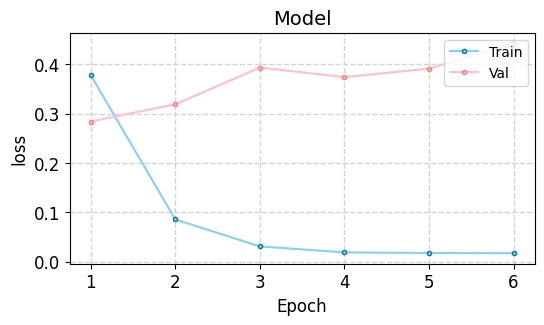

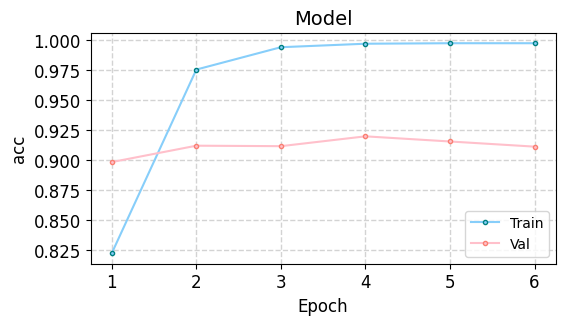

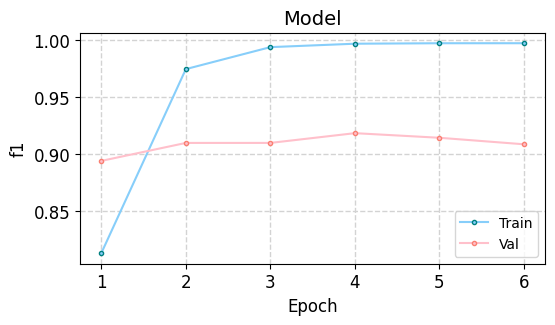

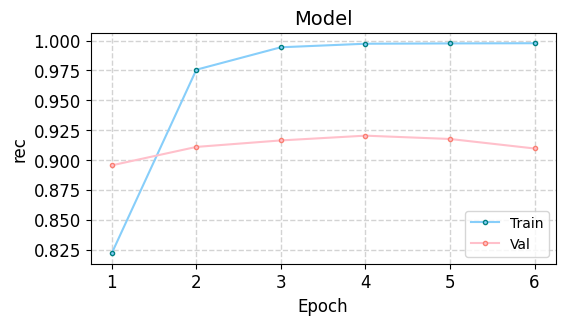

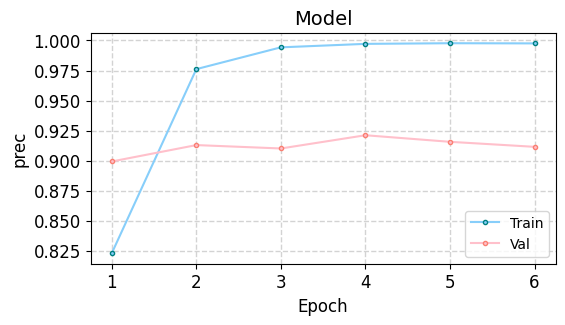

In [23]:
# draw learning curve
import matplotlib.pyplot as plt

def draw_pics(record, name, img_save=False, show=False):
    x_ticks = range(1, len(record['train_'+name]) + 1)  # 改成實際長度

    plt.figure(figsize=(6, 3))

    plt.plot(x_ticks, record['train_'+name], '-o', color='lightskyblue',
             markeredgecolor="teal", markersize=3, markeredgewidth=1, label='Train')
    plt.plot(x_ticks, record['val_'+name], '-o', color='pink',
             markeredgecolor="salmon", markersize=3, markeredgewidth=1, label='Val')
    plt.grid(color='lightgray', linestyle='--', linewidth=1)

    plt.title('Model', fontsize=14)
    plt.ylabel(name, fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.xticks(x_ticks, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(loc='lower right' if not name.lower().endswith('loss') else 'upper right')

    if img_save:
        plt.savefig(name+'.png', transparent=False, dpi=300)
    if show:
        plt.show()

    plt.close()


draw_pics(record, 'loss', img_save=False, show=True)
draw_pics(record, 'acc', img_save=False, show=True)
draw_pics(record, 'f1', img_save=False, show=True)
draw_pics(record, 'rec', img_save=False, show=True)
draw_pics(record, 'prec', img_save=False, show=True)

In [25]:
import torch.nn.functional as F  # 如果還沒 import

def Softmax(x):
  return torch.exp(x) / torch.exp(x).sum()
# label to class
def label2class(label):
    l2c = {0:'negative', 1:'positive'}
    return l2c[label]

def predict_one(query, model):
    model.eval()
    tokenizer = AutoTokenizer.from_pretrained(parameters["config"])

    inputs = tokenizer(
        query,
        padding='max_length',
        truncation=True,
        max_length=parameters["max_len"],
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}  # 全部丟進device

    with torch.no_grad():
        if 'token_type_ids' in inputs:
            logits = model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                token_type_ids=inputs['token_type_ids']
            )
        else:
            logits = model(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask']
            )

    probs = F.softmax(logits.squeeze(), dim=-1)  # 保險起見指定dim
    pred_label = torch.argmax(probs).item()
    pred = label2class(pred_label)

    return probs.cpu(), pred

def predict(data_loader, model):
    """
    對 DataLoader 做推論：
        - train/val loader 回傳 (ids, mask, token_type_ids, labels)
        - test loader 可能回傳 (ids, mask) 或 (ids, mask, token_type_ids)
    回傳：
        - total_probs: List[Tensor]，每筆的 class 機率向量
        - total_pred:  List[int]，每筆的預測 label
    """
    total_probs, total_pred = [], []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            # train/val 模式
            if len(batch) == 4:
                input_ids, attention_mask, token_type_ids, _ = [t.to(device) for t in batch]
            # test 模式：三元組 (ids,mask,token_type_ids)
            elif len(batch) == 3:
                input_ids, attention_mask, token_type_ids = [t.to(device) for t in batch]
            # test 模式：二元組 (ids,mask)
            elif len(batch) == 2:
                input_ids, attention_mask = [t.to(device) for t in batch]
                token_type_ids = None
            else:
                raise ValueError(f"❌ Unexpected batch size: {len(batch)}")

            # forward
            if token_type_ids is not None:
                logits = model(input_ids=input_ids,
                                attention_mask=attention_mask,
                                token_type_ids=token_type_ids)
            else:
                logits = model(input_ids=input_ids,
                                attention_mask=attention_mask)

            # 取得機率與預測
            probs = F.softmax(logits, dim=1)   # [batch, num_class]
            preds = torch.argmax(probs, dim=1) # [batch]

            # 收集
            total_probs.extend(probs.cpu())
            total_pred.extend(preds.cpu().tolist())

    return total_probs, total_pred

In [ ]:
import torch
from transformers import AutoConfig
# 假設 parameters["config"] = "bert-base-uncased" 或 "roberta-base"
# 先拿 config（只會下載一小個 JSON）
config = AutoConfig.from_pretrained(parameters["config"], local_files_only=True)

# 依照你的 config 選擇對應的 Classifier
if "roberta" in parameters["config"]:
    model = RobertaClassifier(config, parameters)
else:
    model = BertClassifier(config, parameters)

# 移到 device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 再 load 你自己訓練好並存成 bert.pt（或 roberta.pt）的檔案
model = load_checkpoint('./bert.pt', model, device).to(device)

Model loaded from <== ./bert.pt


In [27]:
%%time
probs, pred = predict_one("This movie doesn't attract me", model)
print(pred) 

negative
CPU times: total: 93.8 ms
Wall time: 355 ms


In [48]:
# ----- load testing data -----
test_df = pd.read_csv('./test.tsv', sep='\t').sample(500).reset_index(drop=True)
test_dataset = CustomDataset('test', test_df, 'text', parameters)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

# ----- 推論 -----
total_probs, total_pred = predict(test_loader, model)

# ----- 整理結果 -----
res = test_df.copy()
res['pred']  = total_pred
res['p0'], res['p1'] = zip(*[p.tolist() for p in total_probs])

# ----- 儲存 -----
res.to_csv('./result.tsv', sep='\t', index=False)
res.head(5)

,text,label,pred,p0,p1
0,"Well, the movie was no terrible, but whomever ...",0,0,0.997456,0.002544
1,In the mid-1930s Hollywood was regaining its c...,1,1,0.002009,0.997991
2,"A typical Clausen film, but then again not typ...",1,1,0.002000,0.998000
3,me and my sister saw the premiere last night.....,1,1,0.002483,0.997517
4,THE AFFAIR is a very bad TV movie from the 197...,0,0,0.997400,0.002600


In [49]:
correct = 0
for idx, pred in enumerate(res['pred']):
  if pred == res['label'][idx]:
    correct += 1
print('test accuracy = %.4f'%(correct/len(test_df)))

test accuracy = 0.9480
